In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd "/content/drive/MyDrive/Master's Thesis/TM Project/"

/content/drive/MyDrive/Master's Thesis/TM Project


In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# !pip install scikit-optimize

In [ ]:
# from skopt import gp_minimize
# from skopt import space

In [48]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat

In [49]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd
dx = (lambd / 50) * k_0

# normalized simulation lengths
lengths = np.array([(6 * lambd) * k_0, (2 * lambd) * k_0, (6 * lambd) * k_0])

# refractive indices
RIs = np.array([3.1, 3.2, 1])

In [50]:
study = 'TE'
field_type = 'E'

In [51]:
reference_device = devices.SlabWaveguide(RIs, lambd, lengths, study, field_type)

In [52]:
memory_type = torch.device('cpu')
dtype = torch.float64
torch.manual_seed(42)
num_modes = 2

In [53]:
base_model = models.discontinuity_capturing_network(1, 256, num_modes, 1, 'RBF')
# base_model = models.vanilla_network(1, 256, num_modes, 1, 'RBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2000, 3000, 4000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 1538


In [54]:
device = devices.SlabWaveguideWithPINNs(RIs, lambd, lengths, study, field_type, base_model, True)

In [55]:
train_agent = trainers.Trainer(dtype, device, memory_type, [samplers.uniform_grid], optimizer, scheduler, dx=dx, num_samples=None, n_lower=None, n_upper=None)

In [56]:
sampler = train_agent.samplers[0]

x = sampler(device, dx, dtype, memory_type)
RI = device.refractive_index(x, format='torch')
discontinuities = device.get_discontinuities(format='torch')
print(discontinuities)
# discontinuities = x[[device.get_discontinuities_index(x[:, 0])]][:, 0].reshape(-1, 1)

tensor([[-6.2832],
        [ 6.2832]], dtype=torch.float64)


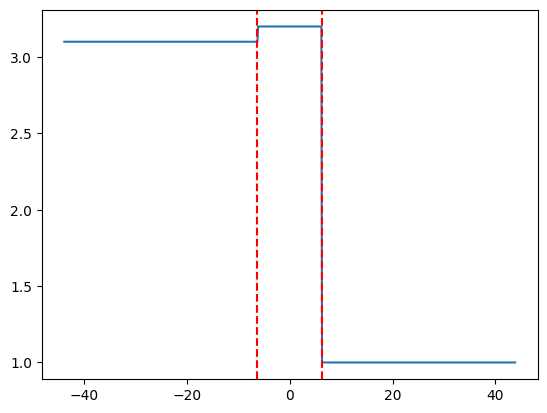

In [57]:
plt.plot(x.cpu(), RI.detach().cpu().numpy())
for discontinuitiy in discontinuities:
  plt.axvline(x=discontinuitiy.cpu(), color='r', linestyle='dashed')

num PDE samples 699
num rayleigh samples 699
iteration 1 loss1 is 0.7912, loss2 is 1.45209, loss3 is -4.87223, loss4 is 0.0294, loss5 is 0.0413, loss6 is 0.63411
mode errors
**********
NN vs analytic
relative error for mode 0 is 106.43366%
**********
**********
NN vs analytic
relative error for mode 1 is 117.40334%
**********


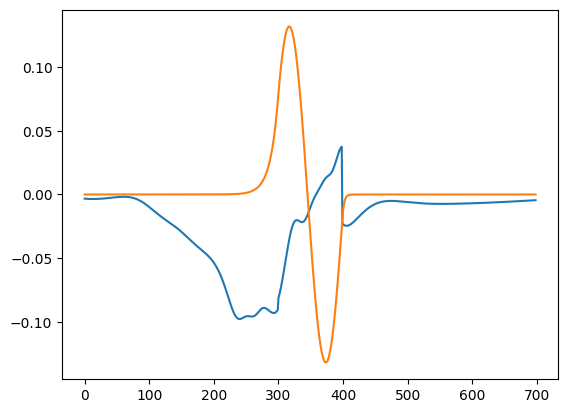

iteration 1001 loss1 is 0.01231, loss2 is 0.00046, loss3 is -15.21087, loss4 is 0.00047, loss5 is 0.00155, loss6 is 0.04704
mode errors
**********
NN vs analytic
relative error for mode 0 is 3.65478%
**********
**********
NN vs analytic
relative error for mode 1 is 3.84522%
**********


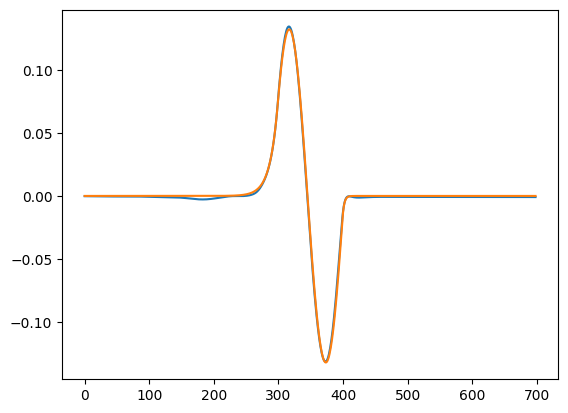

iteration 2001 loss1 is 0.01475, loss2 is 0.00033, loss3 is -15.21095, loss4 is 0.00065, loss5 is 0.00145, loss6 is 0.02275
mode errors
**********
NN vs analytic
relative error for mode 0 is 3.1587%
**********
**********
NN vs analytic
relative error for mode 1 is 4.24681%
**********


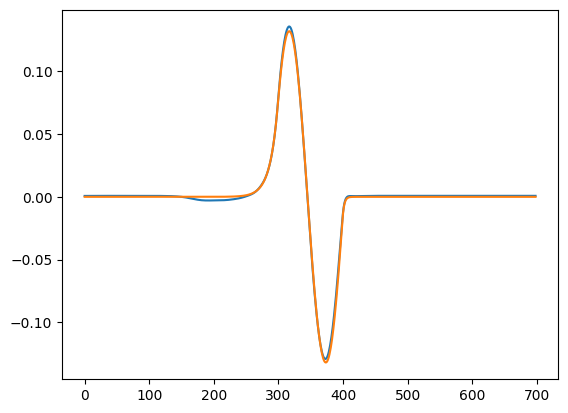

iteration 3001 loss1 is 0.00296, loss2 is 0.00029, loss3 is -15.21245, loss4 is 0.00019, loss5 is 0.00014, loss6 is 0.0036
mode errors
**********
NN vs analytic
relative error for mode 0 is 1.15287%
**********
**********
NN vs analytic
relative error for mode 1 is 1.55997%
**********


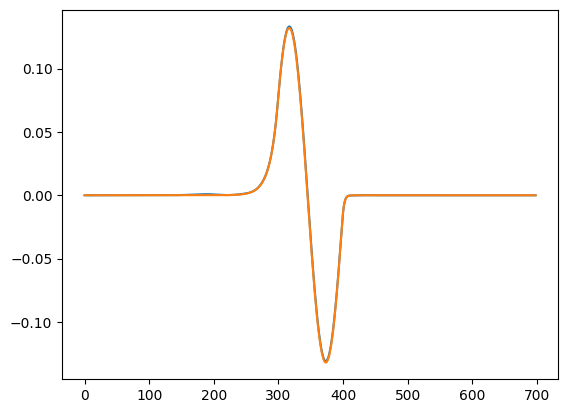

iteration 4001 loss1 is 0.00148, loss2 is 8e-05, loss3 is -15.2123, loss4 is 0.0, loss5 is 5e-05, loss6 is 0.00051
mode errors
**********
NN vs analytic
relative error for mode 0 is 0.46685%
**********
**********
NN vs analytic
relative error for mode 1 is 0.63493%
**********


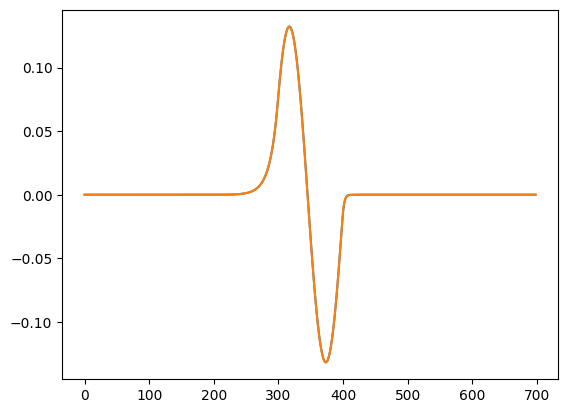

iteration 5001 loss1 is 0.00118, loss2 is 6e-05, loss3 is -15.21229, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.00017
mode errors
**********
NN vs analytic
relative error for mode 0 is 0.37776%
**********
**********
NN vs analytic
relative error for mode 1 is 0.64806%
**********


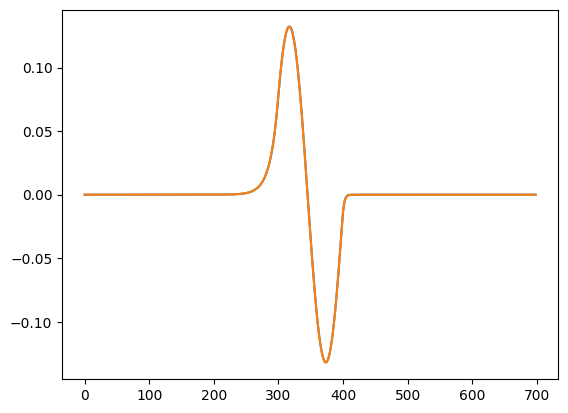

iteration 6001 loss1 is 0.00114, loss2 is 6e-05, loss3 is -15.21229, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.0001
mode errors
**********
NN vs analytic
relative error for mode 0 is 0.38271%
**********
**********
NN vs analytic
relative error for mode 1 is 0.69478%
**********


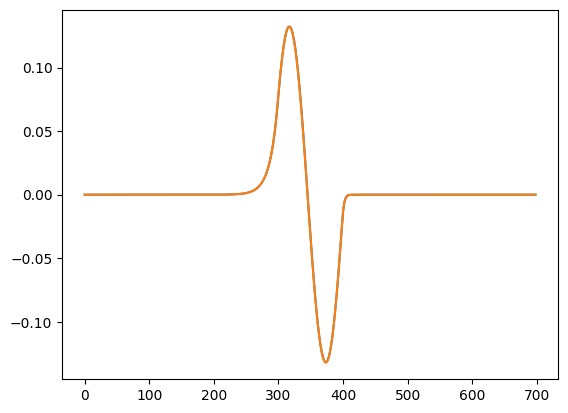

iteration 7001 loss1 is 0.00112, loss2 is 7e-05, loss3 is -15.21229, loss4 is 0.0, loss5 is 0.0, loss6 is 6e-05
mode errors
**********
NN vs analytic
relative error for mode 0 is 0.41707%
**********
**********
NN vs analytic
relative error for mode 1 is 0.7423%
**********


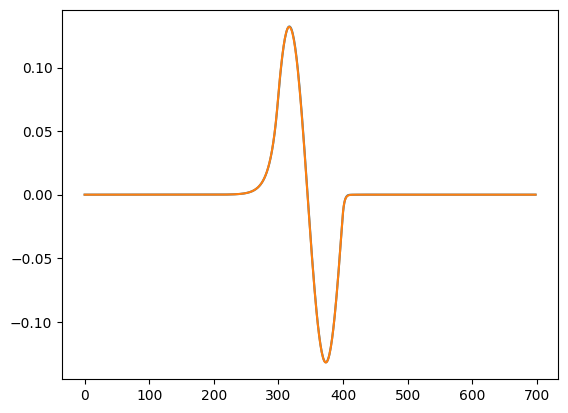

iteration 8001 loss1 is 0.00117, loss2 is 9e-05, loss3 is -15.21229, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.00058
mode errors
**********
NN vs analytic
relative error for mode 0 is 0.41101%
**********
**********
NN vs analytic
relative error for mode 1 is 0.74234%
**********


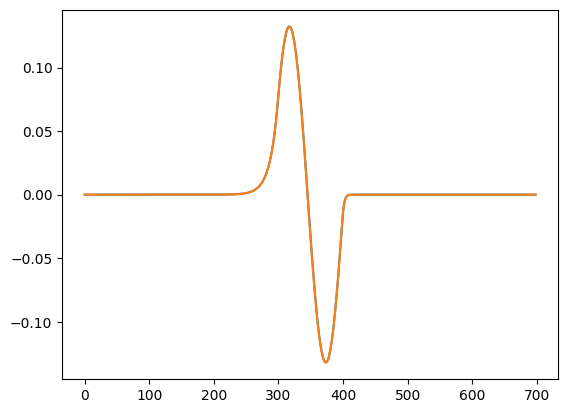

iteration 9001 loss1 is 0.00113, loss2 is 7e-05, loss3 is -15.21229, loss4 is 0.0, loss5 is 1e-05, loss6 is 7e-05
mode errors
**********
NN vs analytic
relative error for mode 0 is 0.45348%
**********
**********
NN vs analytic
relative error for mode 1 is 0.75646%
**********


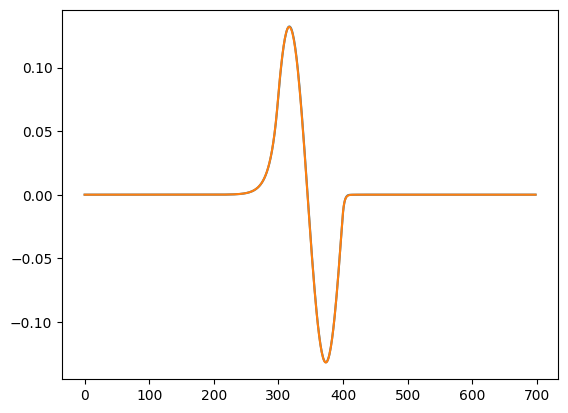

iteration 10001 loss1 is 0.00113, loss2 is 6e-05, loss3 is -15.21229, loss4 is 0.0, loss5 is 1e-05, loss6 is 9e-05
mode errors
**********
NN vs analytic
relative error for mode 0 is 0.49447%
**********
**********
NN vs analytic
relative error for mode 1 is 0.75184%
**********


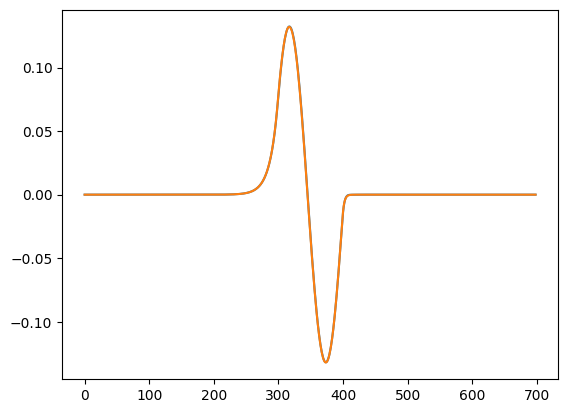

In [58]:
# loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1, 1, 1, 1, 1], verbose=1, sample_new=False)
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[10, 0.5, 2, 1, 1, 1], verbose=1, calc_error=True, plot_solution=False, sample_new=False)